# Customer Churn Analysis – Data Preparation

This notebook performs the **data preprocessing stage** for the Customer Churn Analysis project.

The goal of this stage is to prepare the raw telecommunications dataset for machine learning and clustering analysis. Proper data preparation improves the quality of the analysis and ensures that the dataset is suitable for modeling.

The preprocessing process includes:

- Loading and inspecting the dataset
- Identifying and handling missing values
- Removing duplicate records
- Encoding categorical variables
- Converting the target variable into a numeric format
- Producing a fully cleaned and structured dataset

The resulting dataset will be saved as a **preprocessed dataset** and used in later stages of the project such as **training/testing split, scaling, clustering analysis, and predictive modeling**.

#### Import Required Libraries

In this step, the essential Python libraries required for data manipulation and analysis are imported.

- **Pandas** is used for handling structured datasets and performing data manipulation.
- **NumPy** provides support for numerical operations.

These libraries form the foundation for data preprocessing and analysis tasks throughout the notebook.

In [2]:
import pandas as pd
import numpy as np

#### Load the Dataset

The telecommunications churn dataset is loaded into the notebook using the Pandas library.

This dataset contains customer information such as:

- Demographic attributes (e.g., gender, senior citizen status)
- Service usage (e.g., phone service, internet service)
- Contract details
- Billing information
- Customer churn status

Loading the dataset allows us to begin exploring its structure and identifying potential data quality issues that need to be addressed during preprocessing.

In [10]:
df = pd.read_csv("C:/Users/Prometheus/.vscode/Customer_Churn_Analysis/Dataset_ATS_v2.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


#### Inspect Dataset Structure

Before performing any preprocessing, it is important to understand the structure of the dataset.

In this step we examine:

- The number of rows and columns in the dataset
- The data types of each feature
- Whether the variables are numerical or categorical

Understanding the dataset structure helps determine which preprocessing techniques will be required, such as encoding categorical variables or applying scaling techniques later in the workflow.

In [11]:
print("Dataset info:")
df.info()
print("\nBasic statistics:")
print(df.describe())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   gender           7043 non-null   str  
 1   SeniorCitizen    7043 non-null   int64
 2   Dependents       7043 non-null   str  
 3   tenure           7043 non-null   int64
 4   PhoneService     7043 non-null   str  
 5   MultipleLines    7043 non-null   str  
 6   InternetService  7043 non-null   str  
 7   Contract         7043 non-null   str  
 8   MonthlyCharges   7043 non-null   int64
 9   Churn            7043 non-null   str  
dtypes: int64(3), str(7)
memory usage: 550.4 KB

Basic statistics:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.758768
std         0.368612    24.559481       30.091650
min         0.000000     0.000000       18.000000
25%         0.000000     9.000000       36.00

#### Identify Missing Values

Missing values can negatively affect the performance of machine learning models and clustering algorithms. Therefore, it is essential to detect and address them during the preprocessing stage.

In this step, we check each column to determine whether any values are missing. If missing values are found, appropriate strategies such as imputation using the median (for numerical variables) or mode (for categorical variables) will be applied.

In [12]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64


#### Remove Duplicate Records

Duplicate records can lead to biased analysis and distort clustering results. Therefore, it is important to check for duplicate entries within the dataset.

If duplicate rows are identified, they will be removed to ensure that each record represents a unique customer.

In [13]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 302
Shape after removing duplicates: (6741, 10)


#### Encode Categorical Variables

Machine learning algorithms and clustering models require numerical input data. However, several variables in the dataset are categorical (text-based), such as:

- Gender
- Internet service type
- Contract type
- Dependents status

To make the dataset suitable for modeling, categorical variables are converted into numerical representations using **One-Hot Encoding**.

One-Hot Encoding creates binary columns for each category, allowing the model to interpret categorical data without introducing unintended ordinal relationships.

In [14]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("Columns after encoding:", df_encoded.columns.tolist())
print("Shape after encoding:", df_encoded.shape)

Columns after encoding: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year', 'Churn_Yes']
Shape after encoding: (6741, 11)


#### Encode Target Variable (Churn)

The target variable **Churn** indicates whether a customer has left the service provider.

The values are originally represented as text:

- Yes
- No

To enable machine learning algorithms to process this variable, it is converted into a binary numerical format:

- **Yes → 1 (Customer churned)**
- **No → 0 (Customer retained)**

This transformation allows churn prediction models to treat the problem as a binary classification task.

In [15]:
df_encoded['Churn'] = df['Churn'].map({'Yes':1,'No':0})
print("Unique values in Churn column:", df_encoded['Churn'].unique())

Unique values in Churn column: [1 0]


#### Verify Processed Dataset

After completing the preprocessing steps, it is important to verify that the dataset is ready for further analysis.

This includes confirming that:

- No missing values remain
- All variables are numeric
- The dataset structure is consistent and suitable for modeling

This verification step ensures that the dataset is fully prepared for the next stage of the project.

In [16]:
print("Dataset info after preprocessing:")
df_encoded.info()
print("\nCheck for missing values:")
print(df_encoded.isnull().sum())
print("\nFirst 5 rows of preprocessed dataset:")
print(df_encoded.head())

Dataset info after preprocessing:
<class 'pandas.DataFrame'>
Index: 6741 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   SeniorCitizen                6741 non-null   int64
 1   tenure                       6741 non-null   int64
 2   MonthlyCharges               6741 non-null   int64
 3   gender_Male                  6741 non-null   bool 
 4   Dependents_Yes               6741 non-null   bool 
 5   PhoneService_Yes             6741 non-null   bool 
 6   MultipleLines_Yes            6741 non-null   bool 
 7   InternetService_Fiber optic  6741 non-null   bool 
 8   Contract_One year            6741 non-null   bool 
 9   Contract_Two year            6741 non-null   bool 
 10  Churn_Yes                    6741 non-null   bool 
 11  Churn                        6741 non-null   int64
dtypes: bool(8), int64(4)
memory usage: 316.0 KB

Check for missing values:
SeniorCitizen  

#### Save Preprocessed Dataset

The final step in the data preparation stage is to save the cleaned and processed dataset.

The dataset is exported as a CSV file named **preprocessed_dataset.csv** and stored in the **Data_Preparation** folder within the project repository.

This file will serve as the input dataset for the next stages of the project, including:

- Training and testing dataset split
- Feature scaling
- Clustering analysis
- Predictive modeling

In [18]:
df_encoded.to_csv("c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/preprocessed_dataset.csv", index=False)
print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


# Train/Test Split

After preprocessing, the dataset is ready to be divided into **training** and **testing** sets. 

- The **training set** is used to fit models and learn patterns from the data.  
- The **testing set** is kept separate to evaluate model performance on unseen data.  

This separation is critical to ensure that the predictive models are **not overfitted** and can generalize to new customers.

We will use **80% of the data for training** and **20% for testing**. A fixed `random_state` is used to ensure reproducibility.

#### Import Libraries

We need scikit-learn's `train_test_split` to divide the dataset into training and testing sets.

In [19]:
from sklearn.model_selection import train_test_split
print("train_test_split imported successfully.")

train_test_split imported successfully.


#### Separate Features and Target Variable

Before splitting, we separate:

- `X`: all feature columns (input variables)  
- `y`: target column (`Churn`)  

This ensures the split applies **features and labels consistently**.

In [20]:
# Separate features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Feature columns:\n", X.columns.tolist())

Features (X) shape: (6741, 11)
Target (y) shape: (6741,)
Feature columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'Contract_One year', 'Contract_Two year', 'Churn_Yes']


#### Split Dataset into Training and Testing Sets

Use `train_test_split` to divide the dataset:

- **Training set:** 80% of the data (used for model training)  
- **Testing set:** 20% of the data (used for model validation)  

The split is **stratified** on the target variable to maintain the same proportion of churned customers in both sets.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Print shapes to confirm
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Check distribution of target in training and testing sets
print("\nChurn distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nChurn distribution in testing set:\n", y_test.value_counts(normalize=True))

Training features shape: (5392, 11)
Testing features shape: (1349, 11)
Training target shape: (5392,)
Testing target shape: (1349,)

Churn distribution in training set:
 Churn
0    0.734236
1    0.265764
Name: proportion, dtype: float64

Churn distribution in testing set:
 Churn
0    0.734618
1    0.265382
Name: proportion, dtype: float64


#### Save Training and Testing Sets

We save the split datasets for **Modeling and clustering**.

- `X_train.csv` and `y_train.csv` for training  
- `X_test.csv` and `y_test.csv` for testing  

This allows all team members and subsequent notebooks to **reuse the exact split** without repeating preprocessing.

In [22]:
# Save features
X_train.to_csv("c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_train.csv", index=False)
X_test.to_csv("c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_test.csv", index=False)

# Save targets
y_train.to_csv("c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/y_train.csv", index=False)
y_test.to_csv("c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/y_test.csv", index=False)

print("Training and testing sets saved successfully in Data_Preparation folder!")

Training and testing sets saved successfully in Data_Preparation folder!


## Feature Scaling

Machine learning algorithms such as **K-Means clustering** and **Artificial Neural Networks (ANN)** are sensitive to the scale of input features.

In this dataset, numerical variables such as **tenure** and **MonthlyCharges** have larger ranges than binary variables. If scaling is not applied, features with larger values may dominate the model training process.

To address this issue, **StandardScaler** from scikit-learn is used to normalize the dataset.

StandardScaler transforms the data using the formula:

\[
z = \frac{x - \mu}{\sigma}
\]

Where:
- \(x\) = original value
- \(\mu\) = mean of the feature
- \(\sigma\) = standard deviation

After scaling:
- Mean ≈ 0
- Standard deviation ≈ 1

This ensures that all features contribute equally during model training.

#### Import Scaling Library

The `StandardScaler` class from the scikit-learn preprocessing module is used to normalize feature values.

In [23]:
from sklearn.preprocessing import StandardScaler

print("StandardScaler imported successfully.")

StandardScaler imported successfully.


#### Inspect Feature Statistics Before Scaling

Before applying scaling, we examine the statistical properties of the training dataset. This allows us to observe the differences in scale between features.

In [24]:
print("Feature statistics BEFORE scaling:\n")
print(X_train.describe())

Feature statistics BEFORE scaling:

       SeniorCitizen       tenure  MonthlyCharges
count    5392.000000  5392.000000     5392.000000
mean        0.168769    33.029859       65.959013
std         0.374582    24.315112       29.636016
min         0.000000     0.000000       18.000000
25%         0.000000    10.000000       42.000000
50%         0.000000    30.000000       71.000000
75%         0.000000    56.000000       90.000000
max         1.000000    72.000000      119.000000


#### Feature Distribution Before Scaling

A boxplot visualization is used to observe the spread and scale of each feature before normalization. Differences in ranges between variables can be clearly seen in this visualization.

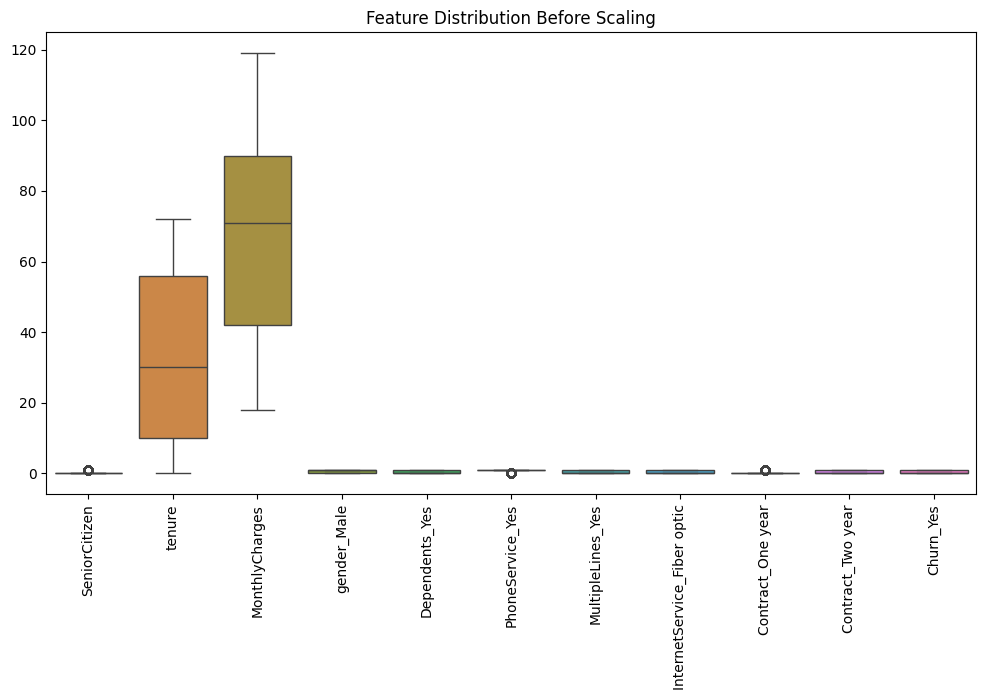

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.title("Feature Distribution Before Scaling")
plt.show()

#### Initialize StandardScaler

The StandardScaler object is initialized. 

The scaler will be **fitted only on the training dataset** to avoid data leakage. The same transformation will then be applied to the testing dataset.

In [26]:
scaler = StandardScaler()

print("StandardScaler initialized.")

StandardScaler initialized.


#### Fit Scaler on Training Data

The scaler is fitted on the training dataset to calculate the mean and standard deviation of each feature.

These statistics will then be used to transform both the training and testing datasets.

In [27]:
scaler.fit(X_train)

print("Scaler fitted to training data.")
print("Feature means learned by scaler:\n", scaler.mean_)
print("Feature standard deviations learned by scaler:\n", scaler.scale_)

Scaler fitted to training data.
Feature means learned by scaler:
 [ 0.16876855 33.02985905 65.95901335  0.50667656  0.30433976  0.89706973
  0.4245178   0.43916914  0.21383531  0.25259644  0.26576409]
Feature standard deviations learned by scaler:
 [ 0.37454736 24.31285711 29.63326767  0.49995542  0.46012723  0.30386778
  0.4942696   0.49628581  0.41001192  0.43450141  0.44173922]


#### Apply Scaling Transformation

The learned scaling parameters are applied to both the training and testing datasets.

This ensures that both datasets are normalized using the same transformation.

In [28]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling applied successfully.")
print("Scaled training dataset shape:", X_train_scaled.shape)
print("Scaled testing dataset shape:", X_test_scaled.shape)

Scaling applied successfully.
Scaled training dataset shape: (5392, 11)
Scaled testing dataset shape: (1349, 11)


#### Convert Scaled Arrays to DataFrames

The scaled outputs are returned as NumPy arrays. For easier inspection and saving, they are converted back into Pandas DataFrames with their original column names.

In [29]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaled datasets converted to DataFrames.")
print(X_train_scaled.head())

Scaled datasets converted to DataFrames.
   SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
0      -0.450593  0.944773        1.486201    -1.013443        1.511887   
1      -0.450593  1.232687       -0.234838    -1.013443       -0.661425   
2      -0.450593  0.821382        0.946267    -1.013443       -0.661425   
3      -0.450593  1.602861        1.621184     0.986735        1.511887   
4      -0.450593 -0.988360        0.338842     0.986735       -0.661425   

   PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
0          0.338734           1.164308                     1.130056   
1          0.338734          -0.858879                    -0.884912   
2          0.338734          -0.858879                    -0.884912   
3          0.338734          -0.858879                    -0.884912   
4          0.338734          -0.858879                    -0.884912   

   Contract_One year  Contract_Two year  Churn_Yes  
0          -0.521534        

#### Verify Scaling Results

After scaling, the feature distributions should have:

- Mean approximately equal to **0**
- Standard deviation approximately equal to **1**

This confirms that the scaling process has been applied correctly.

In [30]:
print("Statistics AFTER scaling:\n")
print(X_train_scaled.describe())

Statistics AFTER scaling:

       SeniorCitizen        tenure  MonthlyCharges   gender_Male  \
count   5.392000e+03  5.392000e+03    5.392000e+03  5.392000e+03   
mean   -6.061752e-17 -1.844881e-17    1.607682e-16 -1.278239e-16   
std     1.000093e+00  1.000093e+00    1.000093e+00  1.000093e+00   
min    -4.505933e-01 -1.358535e+00   -1.618418e+00 -1.013443e+00   
25%    -4.505933e-01 -9.472296e-01   -8.085174e-01 -1.013443e+00   
50%    -4.505933e-01 -1.246196e-01    1.701124e-01  9.867349e-01   
75%    -4.505933e-01  9.447734e-01    8.112837e-01  9.867349e-01   
max     2.219296e+00  1.602861e+00    1.789914e+00  9.867349e-01   

       Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
count    5.392000e+03      5.392000e+03       5.392000e+03   
mean    -7.906633e-17      3.821539e-17      -1.054218e-17   
std      1.000093e+00      1.000093e+00       1.000093e+00   
min     -6.614252e-01     -2.952171e+00      -8.588790e-01   
25%     -6.614252e-01      3.387337e-01      -8.58

#### Feature Distribution After Scaling

The boxplot below shows the distribution of the scaled features. The scales of the variables are now normalized, allowing models to treat all features equally.

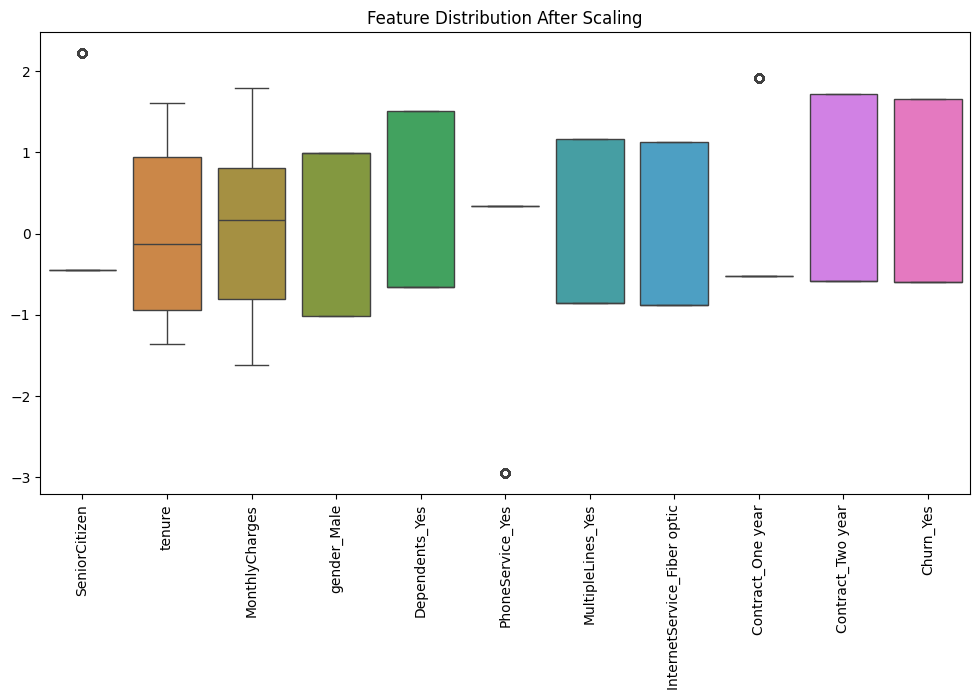

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train_scaled)
plt.xticks(rotation=90)
plt.title("Feature Distribution After Scaling")
plt.show()

#### Save Scaled Datasets

The normalized datasets are saved for use in later stages of the project, including clustering analysis and predictive modeling.

Saving these datasets ensures reproducibility and allows other notebooks to reuse the processed data.

In [34]:
X_train_scaled.to_csv(
r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_train_scaled.csv",
index=False)

X_test_scaled.to_csv(
r"c:/Users/Prometheus/.vscode/Customer_Churn_Analysis/X_test_scaled.csv",
index=False)

print("Scaled datasets saved successfully.")

Scaled datasets saved successfully.
